In [3]:
## IMPORTS AND SETUP
# Imports
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.callbacks import TensorBoard
import datetime
import subprocess

# Tensorboard setup
log_dir = "/workspace/logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    update_freq='epoch'
)

In [4]:
## DATA PREPARATION
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

In [5]:
## MODEL INITIALIZATION
def create_model(input_shape1, input_shape2, output_shape, activation):
    model = tf.keras.models.Sequential([
      tf.keras.layers.Flatten(input_shape=(input_shape1, input_shape2)),
      tf.keras.layers.Dense(output_shape, activation=activation),
      tf.keras.layers.Dropout(0.4),
      tf.keras.layers.Dense(10)
    ])
    return model

In [6]:
## EXECUTION
# Model init
mymodel = create_model(28, 28, 128, 'relu')
mymodel.summary()

predictions = mymodel(x_train[:1]).numpy()

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
loss_fn(y_train[:1], predictions).numpy()

mymodel.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

# Training
history = mymodel.fit(
    x_train,
    y_train,
    epochs=30,
    validation_split=0.25,
    verbose=2,
    callbacks=[tensorboard_callback]
)

# Evaluation
mymodel.evaluate(x_test,  y_test, verbose=2)

# Save model
print(f"Répertoire actuel : {os.getcwd()}")
os.makedirs('model', exist_ok=True)
mymodel.save(os.path.join('model', 'my_model.keras'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1407/1407 - 4s - 3ms/step - accuracy: 0.8841 - loss: 0.3941 - val_accuracy: 0.9476 - val_loss: 0.1849
Epoch 2/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9382 - loss: 0.2066 - val_accuracy: 0.9584 - val_loss: 0.1380
Epoch 3/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9509 - loss: 0.1642 - val_accuracy: 0.9639 - val_loss: 0.1173
Epoch 4/30
1407/1407 - 5s - 4ms/step - accuracy: 0.9569 - loss: 0.1411 - val_accuracy: 0.9687 - val_loss: 0.1096
Epoch 5/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9621 - loss: 0.1245 - val_accuracy: 0.9693 - val_loss: 0.1054
Epoch 6/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9655 - loss: 0.1132 - val_accuracy: 0.9715 - val_loss: 0.0943
Epoch 7/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9674 - loss: 0.1063 - val_accuracy: 0.9707 - val_loss: 0.0946
Epoch 8/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9694 - loss: 0.0976 - val_accuracy: 0.9735 - val_loss: 0.0905
Epoch 9/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9707 - loss: 0.0900 - val_accuracy: 0.9753 - 

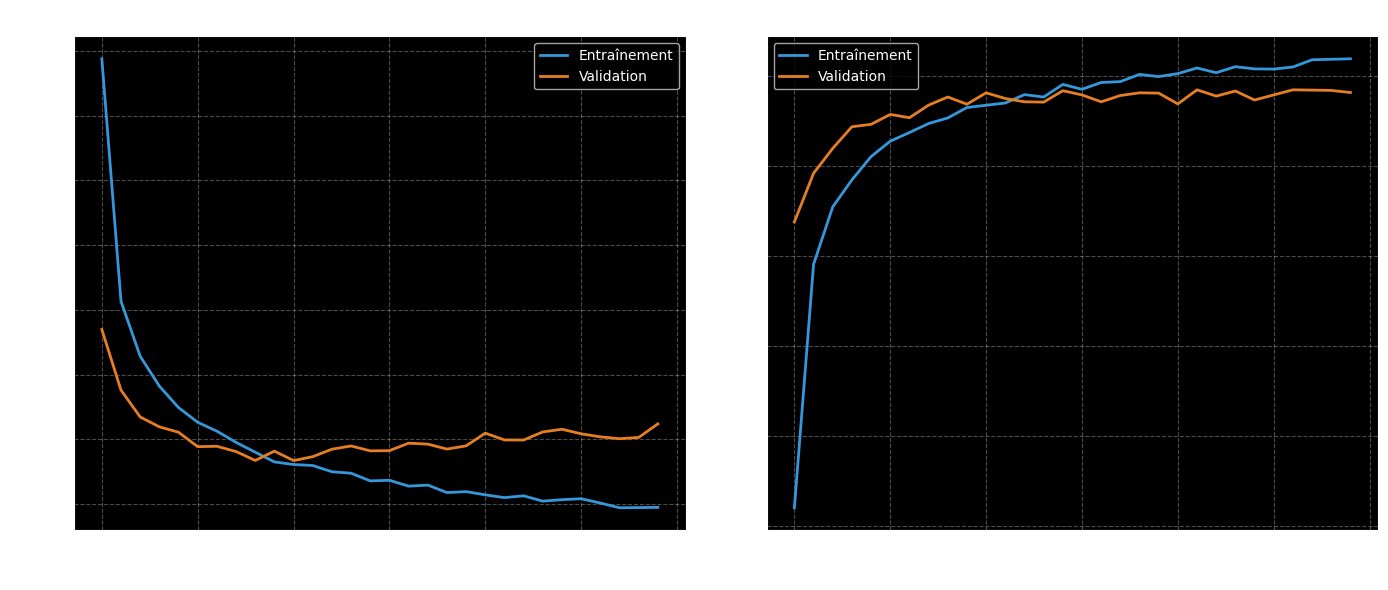

In [7]:
## VISUALIZATION
plt.figure(figsize=(14, 6))
plt.style.use('dark_background')

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color='#3498db', linewidth=2, label='Entraînement')
plt.plot(history.history['val_loss'], color='#e67e22', linewidth=2, label='Validation')
plt.title('Évolution de la perte (Loss)', fontsize=14, fontweight='bold')
plt.ylabel('Valeur de perte', fontsize=12)
plt.xlabel('Époque', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, loc='best')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], color='#3498db', linewidth=2, label='Entraînement')
plt.plot(history.history['val_accuracy'], color='#e67e22', linewidth=2, label='Validation')
plt.title('Évolution de la précision (Accuracy)', fontsize=14, fontweight='bold')
plt.ylabel('Précision', fontsize=12)
plt.xlabel('Époque', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, loc='best')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=300)  # Sauvegarde haute résolution
plt.show()